In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="whitegrid")

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sélection des features
df['hour'] = df['full_timestamp'].dt.hour
features = ['log_total_input', 'fee_rate', 'hour']
X = df[features].fillna(0)

# Splitting (80% pour apprendre, 20% pour tester)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Normalisation : on ajuste le scaler sur le TRAIN uniquement pour éviter le "Data Leakage"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # On utilise les mêmes paramètres pour le test

In [10]:
from sklearn.ensemble import IsolationForest

# Initialisation
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# ENTRAÎNEMENT (Le modèle apprend ce qu'est une transaction "normale")
iso_forest.fit(X_train_scaled)

print("✅ Modèle Isolation Forest entraîné sur le Training Set.")

✅ Modèle Isolation Forest entraîné sur le Training Set.


In [11]:
# PRÉDICTION sur le set de test
y_pred_test = iso_forest.predict(X_test_scaled)

# Conversion (1 = Anomalie, 0 = Normal)
anomalies_test = (y_pred_test == -1).sum()

print(f"Sur le Test Set (données inconnues), l'IA a détecté {anomalies_test} anomalies.")

Sur le Test Set (données inconnues), l'IA a détecté 94 anomalies.


In [12]:
iso_forest

IsolationForest(contamination=0.01, random_state=42)

In [13]:
y_pred_test

array([1, 1, 1, ..., 1, 1, 1])

In [14]:
anomalies_test

94

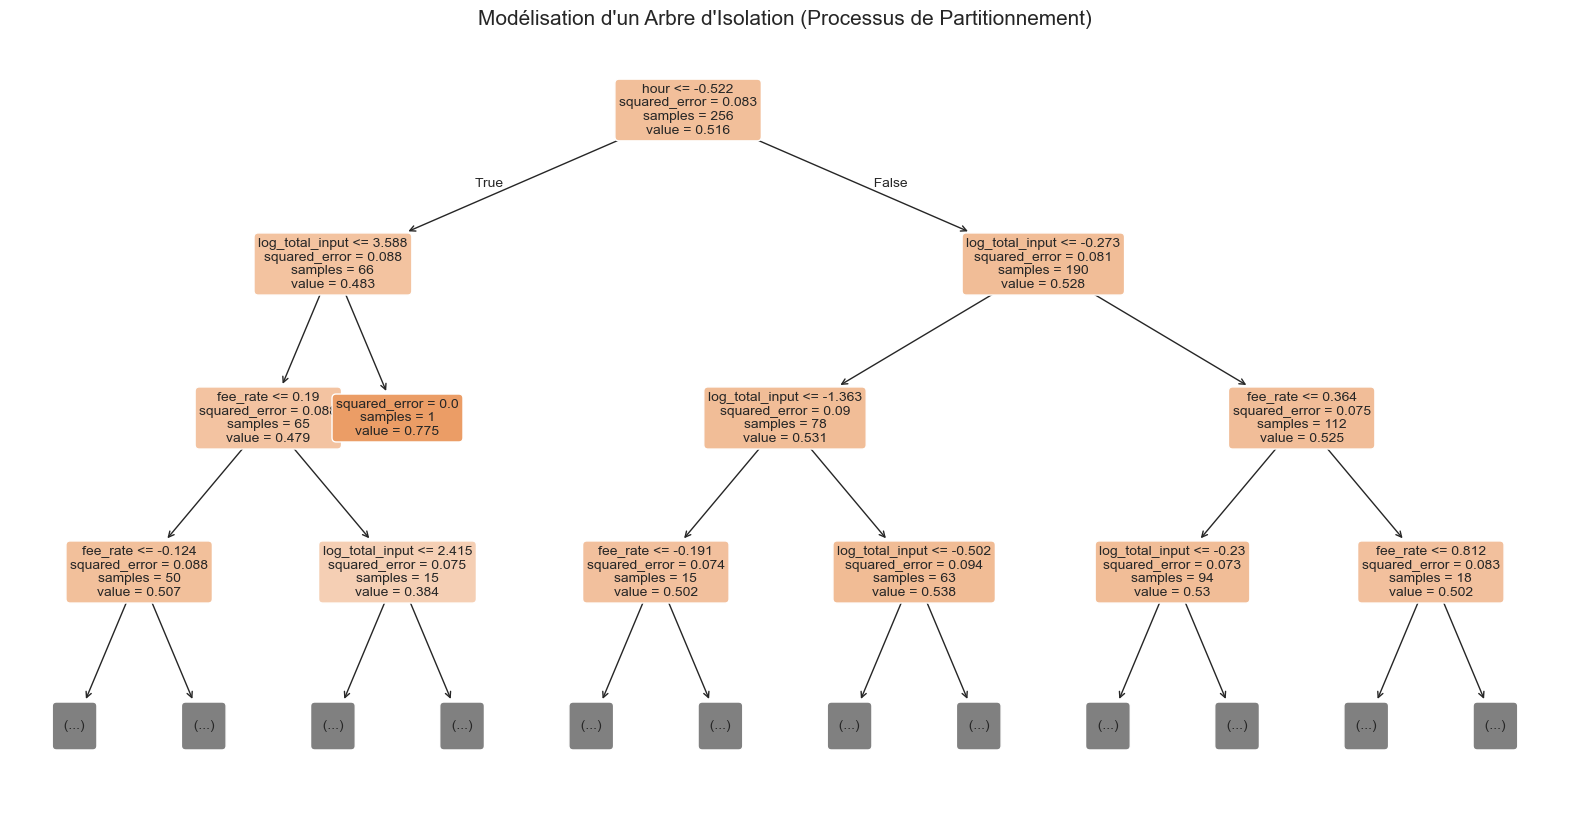

In [15]:
from sklearn.tree import plot_tree

# 1. On récupère le premier arbre de la forêt déjà entraînée
# iso_forest est ton modèle entraîné précédemment
extra_tree = iso_forest.estimators_[0]

# 2. Visualisation
plt.figure(figsize=(20, 10))
plot_tree(extra_tree, 
          feature_names=features, 
          max_depth=3, # On limite la profondeur pour que ce soit lisible
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Modélisation d'un Arbre d'Isolation (Processus de Partitionnement)", fontsize=15)
plt.show()

In [16]:
from sklearn.cluster import DBSCAN

# DBSCAN analyse l'ensemble du set de test pour voir quels points sont isolés
dbscan = DBSCAN(eps=0.5, min_samples=10)
test_clusters = dbscan.fit_predict(X_test_scaled)

anomalies_dbscan = (test_clusters == -1).sum()
print(f"DBSCAN a identifié {anomalies_dbscan} zones de faible densité dans le Test Set.")

DBSCAN a identifié 55 zones de faible densité dans le Test Set.


In [18]:
dbscan

DBSCAN(min_samples=10)

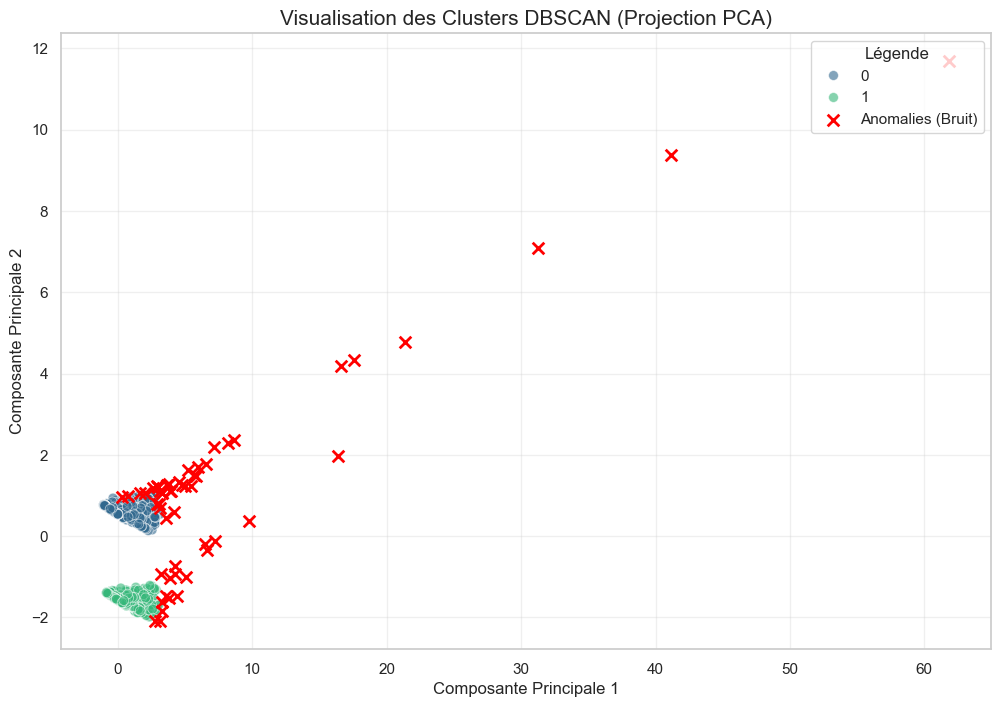

In [17]:
from sklearn.decomposition import PCA

# 1. Réduction de dimension avec PCA (3D/4D -> 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

# 2. Création d'un DataFrame temporaire pour le plot
df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_plot['cluster'] = test_clusters # Les résultats de ton dbscan.fit_predict

# 3. Visualisation
plt.figure(figsize=(12, 8))

# On trace les points normaux (Clusters >= 0)
sns.scatterplot(
    data=df_plot[df_plot['cluster'] != -1], 
    x='PC1', y='PC2', 
    hue='cluster', 
    palette='viridis', 
    alpha=0.6, s=50, 
    legend='full'
)

# On trace les ANOMALIES en rouge (Cluster == -1)
sns.scatterplot(
    data=df_plot[df_plot['cluster'] == -1], 
    x='PC1', y='PC2', 
    color='red', 
    label='Anomalies (Bruit)', 
    s=70, marker='x', linewidth=2
)

plt.title("Visualisation des Clusters DBSCAN (Projection PCA)", fontsize=15)
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title="Légende", loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()